#Ejercicio 2: Sistemas de Recomendación

In [1]:
import pandas as pd
import json

def load_jsonl(path, limit=None):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit and i >= limit:
                break
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

df = load_jsonl("Digital_Music.jsonl")
df.head()




,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Nice,If i had a dollar for how many times I have pl...,[],B004RQ2IRG,B004RQ2IRG,AFUOYIZBU3MTBOLYKOJE5Z35MBDA,1618972613292,0,True
1,5.0,Excellent,awesome sound - cant wait to see them in perso...,[],B0026UZEI0,B0026UZEI0,AHGAOIZVODNHYMNCBV4DECZH42UQ,1308167525000,0,True
2,5.0,Great service,This is a great cd. Good music and plays well....,[],B0055JSYHC,B0055JSYHC,AFGEM6BXCYHUILEOA3P2ZYBEF2TA,1615838793006,0,True
3,1.0,No good,"These are not real German singers, they have a...",[],B000F9SMUQ,B000F9SMUQ,AH3OG6QD6EDJGZRVCFKV4B66VWNQ,1405219741000,0,True
4,3.0,"Cool concept, so-so execution...",I first heard this playing in a Nagoya shop an...,[],B0049D1WVK,B0049D1WVK,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,1309029595000,0,False


C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_10312\2684089920.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.index, y=top_items.values, palette="viridis")


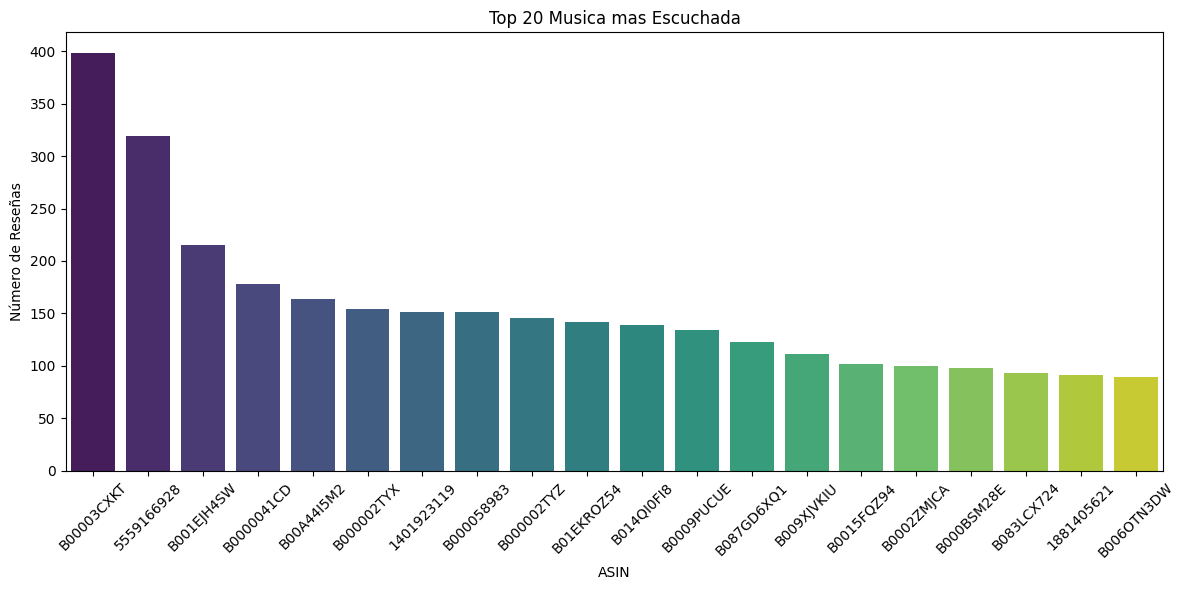

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_items = df['asin'].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_items.index, y=top_items.values, palette="viridis")
plt.xticks(rotation=45)
plt.title('Top 20 Más Reseñadas')
plt.xlabel('ASIN')
plt.ylabel('Número de Reseñas')
plt.tight_layout()
plt.show()

In [3]:
df[['rating', 'helpful_vote']].describe()

,rating,helpful_vote
count,130434.000000,130434.000000
mean,4.532837,1.045050
std,1.027994,3.485248
min,1.000000,0.000000
25%,5.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,1.000000
max,5.000000,259.000000


In [4]:
df2 = df[['user_id', 'asin']].dropna()
df2.columns = ['user', 'item']

In [5]:
user_counts = df2['user'].value_counts()
valid_users = user_counts[user_counts >= 2].index

df2 = df2[df2['user'].isin(valid_users)]
df2.shape

(42350, 2)

In [7]:
transactions = df2.groupby('user')['item'].apply(list)

print("Tipo: ", type(transactions))
print("Usuarios encontrados: ", len(transactions))
print("Primeras 5 canciones:\n")
for t in transactions.head(5):
    print(t)

Tipo:  <class 'pandas.core.series.Series'>
Usuarios encontrados:  12868
Primeras 5 canciones:

['B00GP4ZMLC', 'B00WIXOQNO', 'B008RADSCW']
['B0B3DMZCBG', 'B0B28HVP2M']
['B00C1UDNL0', 'B00J3J0DQA']
['B071DSJ9WN', 'B001LERHCI']
['B00G2J8PVO', 'B000065M1T', 'B0009HN628']


In [13]:
import pandas as pd

transactions_df = pd.DataFrame({'items': transactions})
transactions_df.head()

,items
user,
AE22236AFRRSMQIKGG7TPTB75QEA,"[B002BS47JE, B000VJTJNE]"
AE2227QSJSF6HV3XTTIGQAPA6WHQ,"[B004XDCJ4A, B00L2FGSFI]"
AE222HFZDH6BPTYFOUWGGU63YSIQ,"[B09BJ1B8W1, B07STYRBY5, B07XF2ZXNG, B07QX99XJ..."
AE222HYUASC3KWAIUKZV2QISUX3A,"[B082R1GMV2, B00SAYCVTQ]"
AE222J2TDTWMZFG53IRQ5I7GMBOQ,"[B00065SL0A, B0050SYK44]"


In [19]:
item_counts = df2['item'].value_counts()
frequent_items = item_counts[item_counts >= 500].index

filtered_transactions = [[item for item in t if item in frequent_items] for t in transactions]
filtered_transactions_df = [{'items': t} for t in filtered_transactions if len(t) > 0]

print("Número de transacciones después del filtrado:", len(filtered_transactions_df))

Número de transacciones después del filtrado: 332233


In [20]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(filtered_transactions).transform(filtered_transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
df_encoded.head()

,0375869026,B00000JRSB,B00004Y57G,B00005NZ1G,B00005TNI6,B000066TS5,B00008J7NZ,B0000C7GHG,B0009VXBAQ,B000A2R54M,...,B08G9J44ZN,B08H75RTZ8,B0914YGQSH,B095JNZGC4,B098JTDPQC,B098RKWHHZ,B099VMT8VZ,B09B1L53CB,B09B4MJ9H3,B09JNR4Y15
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [24]:
import time
from mlxtend.frequent_patterns import fpgrowth

start_time = time.time()
frequent_itemsets = fpgrowth(df_encoded, min_support=0.0001, use_colnames=True)
end_time = time.time()

print("Tiempo de ejecución:", end_time - start_time, "segundos")
frequent_itemsets.head()

Tiempo de ejecución: 279.9796965122223 segundos


,support,itemsets
0,0.001134,(B00L2FGSFI)
1,0.001585,(B00SAYCVTQ)
2,0.000839,(B0050SYK44)
3,0.001065,(B071RSSMLL)
4,0.002899,(B0050SYILE)


In [46]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

print("Número de reglas generadas:", len(rules))
rules.head()

Número de reglas generadas: 3


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(B01C93CWSI),(B01C93CWU6),0.001409,0.001356,0.000447,0.317636,234.162439,1.0,0.000445,1.463506,0.997134,0.193042,0.316709,0.323727
1,(B01C93CWU6),(B01C93CWSI),0.001356,0.001409,0.000447,0.329818,234.162439,1.0,0.000445,1.490030,0.997082,0.193042,0.328873,0.323727
2,(B001PO2BJI),(B001GIUWX0),0.000983,0.001371,0.000337,0.342593,249.924547,1.0,0.000335,1.519042,0.996979,0.166989,0.341690,0.294162


In [26]:
recommendation_dict = {}

for idx, row in rules.iterrows():
    antecedent = tuple(sorted(row['antecedents']))
    consequent = list(row['consequents'])[0]

    if antecedent not in recommendation_dict:
        recommendation_dict[antecedent] = []

    recommendation_dict[antecedent].append({
        'item': consequent,
        'support': row['support'],
        'confidence': row['confidence'],
        'lift': row['lift']
    })

In [36]:
def recomendaciones(cart, rules_df, top_n=5):
    cart = set(cart)
    candidate_recommendations = []

    for idx, row in rules_df.iterrows():
        antecedent = row['antecedents']
        consequent = list(row['consequents'])[0]

        if antecedent.issubset(cart) and consequent not in cart:
            candidate_recommendations.append((
                consequent, row['confidence'], row['lift']))

    candidate_recommendations = sorted(candidate_recommendations, key=lambda x: (x[2], x[1]), reverse=True)

    seen = set()
    result = []
    for item, conf, lift in candidate_recommendations:
        if item not in seen:
            result.append({'item': item, 'confidence': conf, 'lift': lift})
            seen.add(item)
        if len(result) >= top_n:
            break
    return result

In [42]:
carro = ['B01FEHJYUU']
print(recomendaciones(carro, rules))

[]
